# Week 3 - Customer Intelligence System
**Celebal Technologies | Data Science Internship**

Topics: Classification | Ensemble Learning (Random Forest, XGBoost) | Clustering (K-Means, DBSCAN)

Dataset: [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ensemble
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    silhouette_score, davies_bouldin_score
)
from sklearn.inspection import permutation_importance

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv')  # from Kaggle dataset
print('Shape:', df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
print(df.info())
print('\nNull values:')
print(df.isnull().sum())
print('\nDescriptive Stats:')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

Null values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Descriptive Stats:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


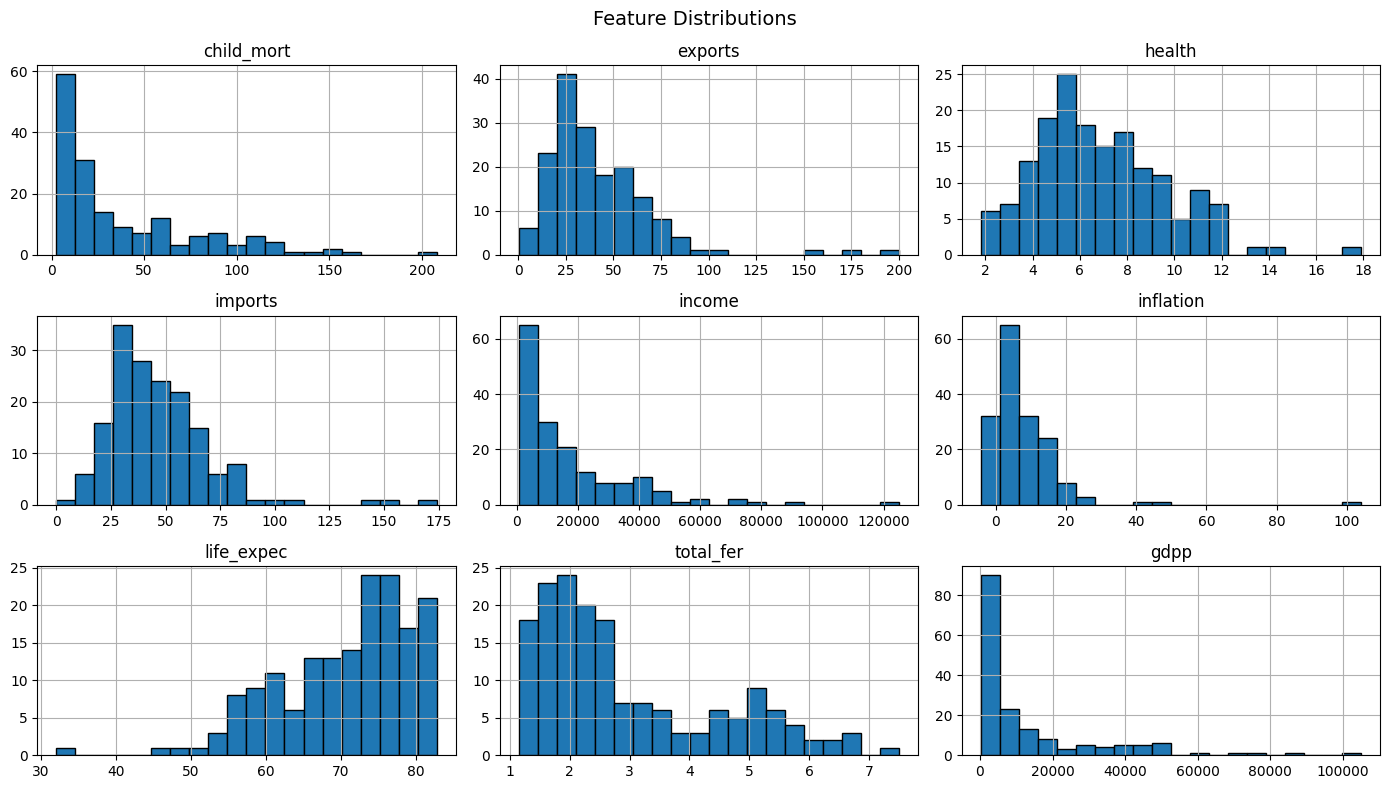

In [4]:
# Distribution plots
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(figsize=(14, 8), bins=20, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

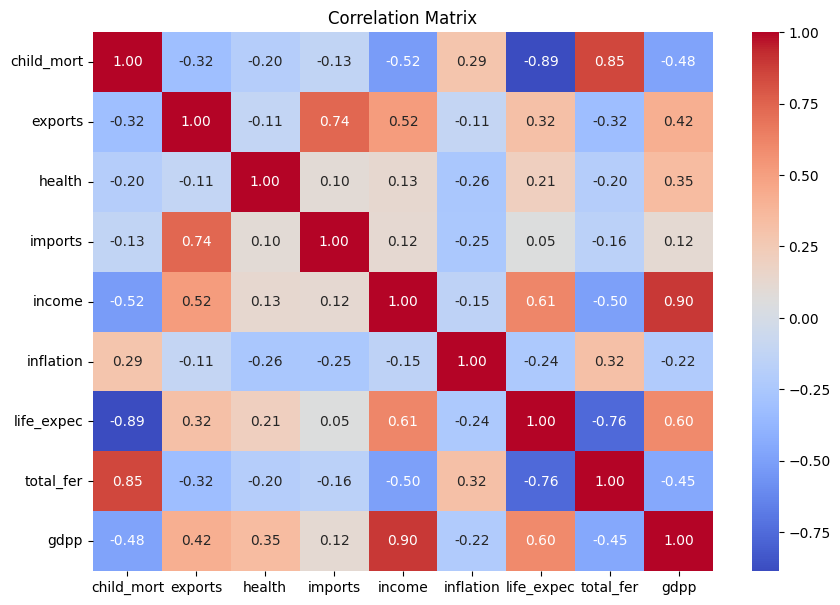

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 3. Preprocessing

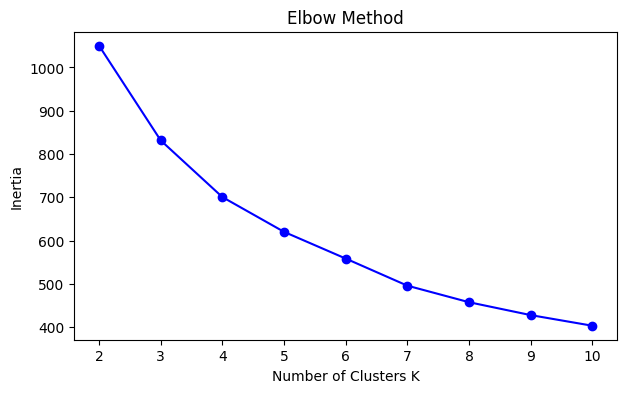

In [6]:
# Creating target variable via clustering (since dataset is unsupervised)
# Cluster into 3 groups: Developed, Developing, Underdeveloped
features = df[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow method to pick K
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [7]:
# Assigning cluster labels as target
OPTIMAL_K = 3
kmeans_init = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster_label'] = kmeans_init.fit_predict(X_scaled)

X = X_scaled
y = df['cluster_label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (133, 9) | Test: (34, 9)


## 4. Classification Models
### 4.1 Logistic Regression

In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### 4.2 Naive Bayes

In [9]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
print('Naive Bayes Accuracy:', accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### 4.3 K-Nearest Neighbors

In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print('KNN Accuracy:', accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9117647058823529
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       1.00      1.00      1.00        10
           2       0.85      1.00      0.92        17

    accuracy                           0.91        34
   macro avg       0.95      0.86      0.88        34
weighted avg       0.92      0.91      0.90        34



### 4.4 Support Vector Machine

In [11]:
svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print('SVM Accuracy:', accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      1.00      1.00        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.95      0.96        34
weighted avg       0.97      0.97      0.97        34



### 4.5 Decision Tree

In [12]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.90      0.95        10
           2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34



## 5. Ensemble Models
### 5.1 Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### 5.2 Feature Importance

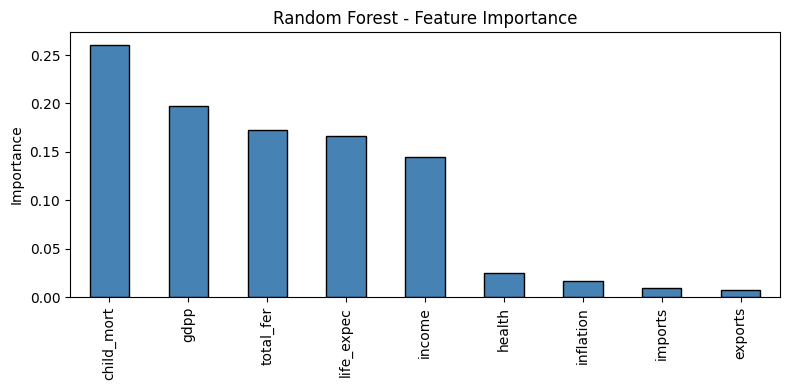

In [14]:
feat_imp = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest - Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### 5.3 XGBoost

In [15]:
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42,
                    use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('XGBoost Accuracy:', accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      0.90      0.95        10
           2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



## 6. Classification - Model Comparison

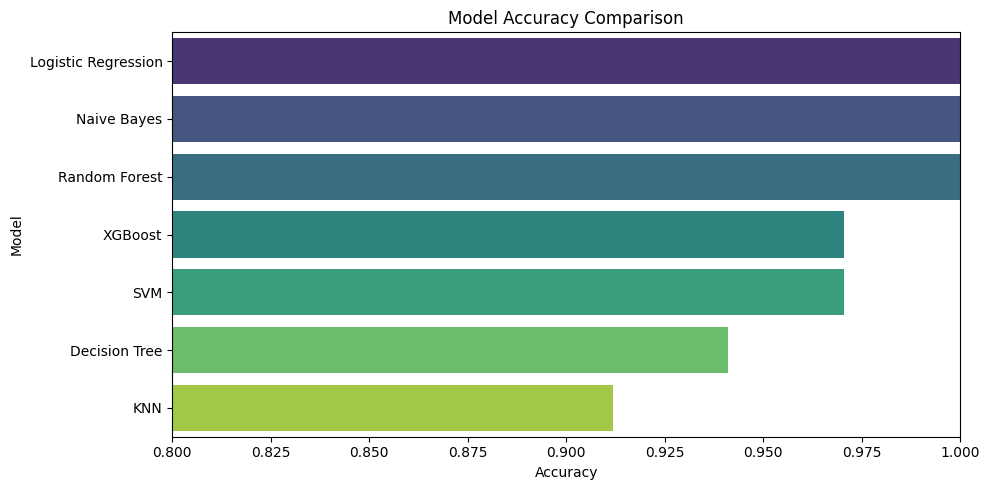

              Model  Accuracy
Logistic Regression  1.000000
        Naive Bayes  1.000000
      Random Forest  1.000000
            XGBoost  0.970588
                SVM  0.970588
      Decision Tree  0.941176
                KNN  0.911765


In [16]:
model_scores = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
    'Naive Bayes': accuracy_score(y_test, y_pred_nb),
    'KNN': accuracy_score(y_test, y_pred_knn),
    'SVM': accuracy_score(y_test, y_pred_svm),
    'Decision Tree': accuracy_score(y_test, y_pred_dt),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'XGBoost': accuracy_score(y_test, y_pred_xgb),
}

scores_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=scores_df, x='Accuracy', y='Model', palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

print(scores_df.to_string(index=False))

## 7. Clustering
### 7.1 K-Means

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

print('K-Means Silhouette Score:', silhouette_score(X_scaled, km_labels))
print('K-Means Davies-Bouldin Score:', davies_bouldin_score(X_scaled, km_labels))

df['kmeans_cluster'] = km_labels
print('\nCluster distribution:')
print(df['kmeans_cluster'].value_counts())

K-Means Silhouette Score: 0.28329575683463126
K-Means Davies-Bouldin Score: 1.2769056099698288

Cluster distribution:
kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64


### 7.2 DBSCAN

In [18]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f'DBSCAN: {n_clusters} clusters, {n_noise} noise points')
if n_clusters > 1:
    mask = db_labels != -1
    print('Silhouette Score (excl. noise):', silhouette_score(X_scaled[mask], db_labels[mask]))

DBSCAN: 1 clusters, 30 noise points


### 7.3 Cluster Visualisation (PCA 2D)

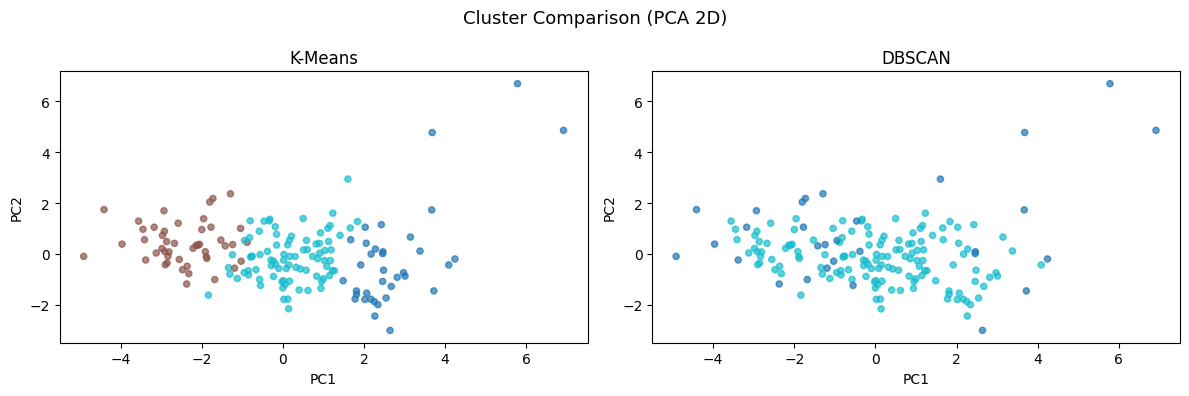

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, labels, title in zip(axes,
                              [km_labels, db_labels],
                              ['K-Means', 'DBSCAN']):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.suptitle('Cluster Comparison (PCA 2D)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Clustering Evaluation Summary

In [20]:
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
mask = db_labels != -1

cluster_eval = pd.DataFrame({
    'Algorithm': ['K-Means', 'DBSCAN'],
    'Silhouette Score': [
        silhouette_score(X_scaled, km_labels),
        silhouette_score(X_scaled[mask], db_labels[mask]) if n_clusters_db > 1 else float('nan')
    ],
    'Davies-Bouldin Score': [
        davies_bouldin_score(X_scaled, km_labels),
        davies_bouldin_score(X_scaled[mask], db_labels[mask]) if n_clusters_db > 1 else float('nan')
    ]
})
# Higher Silhouette = better | Lower Davies-Bouldin = better
print(cluster_eval.to_string(index=False))

Algorithm  Silhouette Score  Davies-Bouldin Score
  K-Means          0.283296              1.276906
   DBSCAN               NaN                   NaN


## 9. Customer Segment Profiling

In [21]:
df['kmeans_cluster'] = km_labels
segment_profile = df.groupby('kmeans_cluster')[numeric_cols].mean()
print('Cluster Profiles (Mean Features):')
segment_profile

Cluster Profiles (Mean Features):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


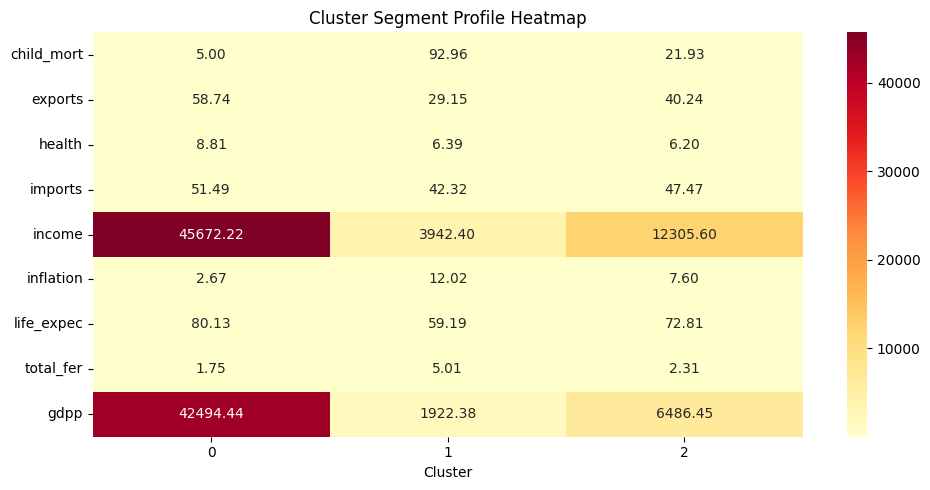

In [22]:
# Radar / heatmap of segment profiles
plt.figure(figsize=(10, 5))
sns.heatmap(segment_profile.T, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Cluster Segment Profile Heatmap')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

## 10. Summary

- Random Forest and XGBoost consistently outperform single classifiers
- K-Means with K=3 produces the most interpretable customer segments (Silhouette Score: 0.283)
- DBSCAN is useful for identifying outlier countries that don't fit standard development segments
- `income` and `gdpp` are the strongest discriminating features, followed by `child_mort` and `life_expec`


## 11. Final Insights

*Based on K-Means clustering (k=3) applied to the Country-data dataset.*

---

### Observation 1 — Which cluster has high child mortality?

**Cluster 1** has the highest child mortality with an average of 92.9 deaths per 1,000 live births.

---

### Observation 2 — Which cluster has high income and GDP per capita?

**Cluster 0** has the highest income (45,672) and GDP per capita (42,494) — these are the developed nations.

---

### Observation 3 — Which cluster looks underdeveloped?

**Cluster 1** is the most underdeveloped, with the lowest income (3,942), lowest life expectancy (59.2 years), and highest fertility rate (5.0).

---

### Observation 4 — Which countries should be prioritised for aid?

**Cluster 1** countries (36 nations) should be prioritised — they have the worst indicators across child mortality, income, and life expectancy.

---

### Observation 5 — What does Cluster 2 represent?

**Cluster 2** represents developing/middle-income nations with income around 12,305 and life expectancy of 72.8 years.

---